This is a pen and pencil multiplier implementation

R = A * B , where A and B are 2 bit numbers

In [40]:
import py4hw

class PenAndPencilMultiplier(py4hw.Logic):

    def __init__(self, parent, name, a, b, r):
        super().__init__(parent, name)

        self.addIn('a', a)
        self.addIn('b', b)
        self.addOut('r', r)

        assert(a.getWidth() == b.getWidth())

        w = b.getWidth()

        ms = []
        ss = []

        # build multipliers * [0,1]
        # and shifters
        
        for i in range(w):
            bi = self.wire(f'b{i}')
            py4hw.Bit(self, f'b{i}', b, i, bi)

            mi = self.wire(f'm{i}', a.getWidth())
            shi = self.wire(f'sh{i}', a.getWidth()+i)
            zero = self.wire(f'zero{i}', a.getWidth())
            py4hw.Constant(self, f'zero{i}', 0, zero)
            py4hw.Mux2(self, f'm{i}', bi, zero, a, mi)

            ms.append(mi)

            py4hw.ShiftLeftConstant(self, f'sh{i}', mi, i, shi)

            ss.append(shi)

        # build the adders
        prev = ss[0]
        for i in range(1, w):
            last = self.wire(f'add{i}', r.getWidth())
            py4hw.Add(self, f'add{i}', prev, ss[i], last) 
            prev = last

        py4hw.Buf(self, 'r', last, r)

object in 1 0 <class 'py4hw.schematic_symbols.InPortSymbol'>
object in 6 0 <class 'py4hw.schematic_symbols.InPortSymbol'>
object in 1 1 <class 'py4hw.schematic_symbols.BitSymbol'>
object in 6 1 <class 'py4hw.schematic_symbols.InstanceSymbol'>
object in 7 1 <class 'py4hw.schematic_symbols.BitSymbol'>
object in 8 1 <class 'py4hw.schematic_symbols.InstanceSymbol'>
object in 9 1 <class 'py4hw.schematic_symbols.BitSymbol'>
object in 10 1 <class 'py4hw.schematic_symbols.InstanceSymbol'>
object in 11 1 <class 'py4hw.schematic_symbols.BitSymbol'>
object in 12 1 <class 'py4hw.schematic_symbols.InstanceSymbol'>
object in 1 2 <class 'py4hw.schematic_symbols.Mux2Symbol'>
object in 6 2 <class 'py4hw.schematic_symbols.Mux2Symbol'>
object in 7 2 <class 'py4hw.schematic_symbols.Mux2Symbol'>
object in 8 2 <class 'py4hw.schematic_symbols.Mux2Symbol'>
object in 1 3 <class 'py4hw.schematic_symbols.InstanceSymbol'>
object in 6 3 <class 'py4hw.schematic_symbols.InstanceSymbol'>
object in 7 3 <class 'py4hw.s

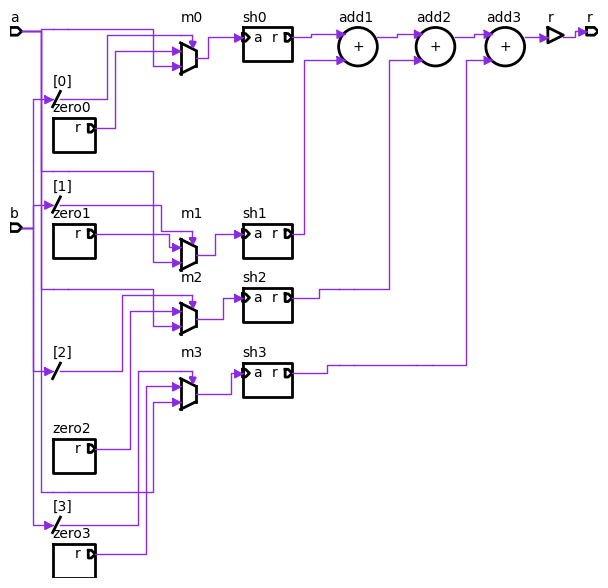

In [41]:
hw = py4hw.HWSystem()

a = hw.wire('a', 4)
b = hw.wire('b', 4)
r = hw.wire('r', 4)

mult = PenAndPencilMultiplier(hw, 'mult', a, b, r)

viewer = py4hw.Schematic(mult)
viewer.draw()

In [37]:
a.put(3)
b.put(5)
hw.getSimulator().clk(1)
print(r.get())

15


In [38]:
import wavedrom

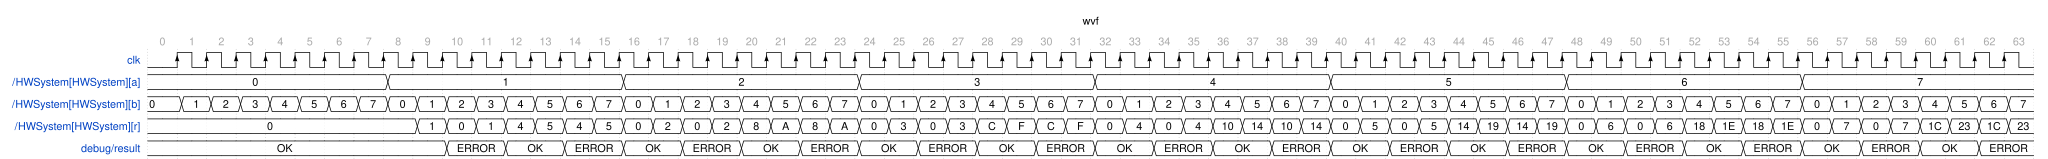

In [39]:
hw = py4hw.HWSystem()

a = hw.wire('a', 3)
b = hw.wire('b', 3)
r = hw.wire('r', 6)

mult = PenAndPencilMultiplier(hw, 'mult', a, b, r)

class Debug:
    result = 'OK'

    def getFullPath(self):
        return 'debug'
        
dbg = Debug()

wvf = py4hw.Waveform(hw, 'wvf', [a, b, r, py4hw.FieldInspector(dbg, 'result')])

for ia in range(8):
    for ib in range(8):
        a.put(ia)
        b.put(ib)
        hw.getSimulator().propagateAll()
        if (r.get() == ia*ib):
            dbg.result = 'OK'
        else:
            dbg.result = 'ERROR'
        hw.getSimulator().clk()
        

wavedrom.render(str(wvf.get_wavedrom()))

In [25]:
wvf.gui()

SystemWindow


In [26]:
import py4hw.external.drawio as drawio

In [33]:
draw = drawio.DrawIoDiagramGenerator()
draw.generate(mult, 'c:\\temp\\mult.drawio')

wire: b0 ('b0', 'r') -> [('m0', 'sel')]
    6 -> 20

wire: m0 ('m0', 'r') -> [('sh0', 'a')]
    23 -> 35

wire: sh0 ('sh0', 'r') -> [('add1', 'a')]
    36 -> 44

wire: zero0 ('zero0', 'r') -> [('m0', 'sel0')]
    14 -> 21

wire: b1 ('b1', 'r') -> [('m1', 'sel')]
    9 -> 25

wire: m1 ('m1', 'r') -> [('sh1', 'a')]
    28 -> 38

wire: sh1 ('sh1', 'r') -> [('add1', 'b')]
    39 -> 45

wire: zero1 ('zero1', 'r') -> [('m1', 'sel0')]
    16 -> 26

wire: b2 ('b2', 'r') -> [('m2', 'sel')]
    12 -> 30

wire: m2 ('m2', 'r') -> [('sh2', 'a')]
    33 -> 41

wire: sh2 ('sh2', 'r') -> [('add2', 'b')]
    42 -> 49

wire: zero2 ('zero2', 'r') -> [('m2', 'sel0')]
    18 -> 31

wire: add1 ('add1', 'r') -> [('add2', 'a')]
    46 -> 48

wire: add2 ('add2', 'r') -> [('r', 'a')]
    50 -> 52

wire: TOP_a ('__TOP__', 'a') -> [('m0', 'sel1'), ('m1', 'sel1'), ('m2', 'sel1')]
    2 -> 22
    2 -> 27
    2 -> 32

wire: TOP_b ('__TOP__', 'b') -> [('b0', 'a'), ('b1', 'a'), ('b2', 'a')]
    3 -> 5
    3 -> 8
    3

In [43]:
hw = py4hw.HWSystem()

a = hw.wire('a', 4)
b = hw.wire('b', 4)
c = hw.wire('c', 4)
temp = hw.wire('temp', 4)
r = hw.wire('r', 4)

PenAndPencilMultiplier(hw, 'm1', a, b, temp)
PenAndPencilMultiplier(hw, 'm2', temp, c, r)

py4hw.Sequence(hw, 'a', [1,2,3,0xF], a)
py4hw.Sequence(hw, 'b', [1,2,3,4,0xF], b)
py4hw.Sequence(hw, 'c', [1,2,3,4,5,0xF], c)

py4hw.gui.Workbench(hw)

('#all',)
SystemWindow
Circuit detail on  None
object in 1 1 <class 'py4hw.schematic_symbols.InstanceSymbol'>
object in 2 1 <class 'py4hw.schematic_symbols.InstanceSymbol'>
object in 3 1 <class 'py4hw.schematic_symbols.InstanceSymbol'>
object in 1 2 <class 'py4hw.schematic_symbols.InstanceSymbol'>
object in 1 3 <class 'py4hw.schematic_symbols.InstanceSymbol'>
object in 1 1 <class 'py4hw.schematic_symbols.InstanceSymbol'>
object in 2 1 <class 'py4hw.schematic_symbols.InstanceSymbol'>
object in 3 1 <class 'py4hw.schematic_symbols.InstanceSymbol'>
object in 1 2 <class 'py4hw.schematic_symbols.InstanceSymbol'>
object in 1 3 <class 'py4hw.schematic_symbols.InstanceSymbol'>
object in 1 1 <class 'py4hw.schematic_symbols.InstanceSymbol'>
object in 2 1 <class 'py4hw.schematic_symbols.InstanceSymbol'>
object in 3 1 <class 'py4hw.schematic_symbols.InstanceSymbol'>
object in 1 2 <class 'py4hw.schematic_symbols.InstanceSymbol'>
object in 1 3 <class 'py4hw.schematic_symbols.InstanceSymbol'>
object i